# Avance de Proyecto — Simulación de Nanofluidos con MXene en geometría L

**Reproducción y extensión del modelo de:**
Pineda, F. *et al.* (2025). *MXene-enhanced nanofluids for superior thermal energy storage
in concentrated solar power plants*. **Solar Energy Materials and Solar Cells, 283**, 113461.
[doi:10.1016/j.solmat.2025.113461](https://doi.org/10.1016/j.solmat.2025.113461)

**Estudiante:** Millaray Antonia Lagos Leiva
**Asignatura:** Física computacional (Fis-205)
**Fecha:** 05/06/2026

---

## Objetivo de este notebook

Este documento acompaña el avance del proyecto ayuda a comprender de mejor manera la estructuración del código

> reorganiza, comenta y *parcha mínimamente* para correr dentro de un Jupyter Notebook.
---


## 1. Marco teórico — ¿Qué simulamos y por qué?

### 1.1 El problema físico

Las plantas de **Energía Solar Concentrada (CSP)** almacenan calor en *sales solares*
fundidas (60 wt-% NaNO₃ + 40 wt-% KNO₃). Subir la temperatura de operación mejora la
eficiencia del ciclo termodinámico, pero la sal se *descompone* químicamente cerca de
los 586 °C, liberando gases nitrosos (NOₓ).

El paper propone añadir **MXene multicapa (Ti₃C₂Tₓ)** —un material 2D— como aditivo
para:
- Aumentar la temperatura de descomposición $T_d$ (medida: 609.8 °C con 3 wt-% de MXene vs 586.2 °C de la sal pura).
- Mejorar la capacidad calorífica específica $C_p$.

### 1.2 La hipótesis que el modelo computacional pone a prueba

| Efecto | Mecanismo en el modelo |
|---|---|
| **Topológico** | Los bloques de MXene ocupan espacio en la grilla y reducen la concentración local de reactantes vecinos. |
| **Energético** | La presencia de MXene aumenta la barrera de activación de la reacción (factor de Boltzmann menor). |

### 1.3 Especificaciones del modelo (paper):

- Grilla 50 × 50 con **condiciones de borde periódicas** (PBC).
- $N_A(0) = N_B(0) = 1000$ unidades de reactantes A y B.
- **Vecindad de Moore** (8 vecinos).
- MXenes representados como bloques $5\times 1$ con orientación aleatoria.
- Reacción directa $A+B \to C+D$ con probabilidad máxima $1/8$ a $T=1$.
- Reacción inversa $C+D \to A+B$ con probabilidad constante $10^{-4}$.
- Producto $D$ es un gas: tiende a *moverse hacia arriba* y escapa del sistema.

### 1.4 La variación de la geometria "L" (proyecto):

En lugar del bloque 5×1 lineal se implementa una **L de 5 celdas**:

```
   X . .          (5 celdas, mismo número que el bloque 5×1 del paper)
   X . .
   X X X
```

3 celdas verticales + 3 celdas horizontales − 1 esquina compartida = **5 celdas**.
Cuatro orientaciones equivalentes a las `up/down/right/left` del paper.


## 2. Imports y configuración

Implementamos los imports, con el parche de `Self`.

In [2]:
from __future__ import annotations
from typing import Any
try:
    from typing import Self          # Python ≥ 3.11
except ImportError:                  
    Self = "Nodes"

from math import exp
import random
import pickle
import copy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

# Reproducibilidad (para verficiar fallas y resultados)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Imports OK")


Imports OK


## 3. Funciones auxiliares

### 3.1 `mef` — *manejo de errores formal*
Atajo para lanzar `RuntimeError` con un mensaje contextualizado.

### 3.2 `fn_reac` — la **probabilidad de reacción**

$$
p_{\text{reac}}(T) = 0.15 \cdot \exp\!\left(-\frac{E_a}{T}\right)
$$

donde la "energía de activación" $E_a$ toma dos valores según el contexto:

- $E_a = 0.2$ si la celda está **libre** de MXene (`is_free=True`).
- $E_a = 2.0$ si está **cerca de un MXene** (`is_free=False`).

El segundo caso modela el *efecto energético* del MXene: necesita ~10× más temperatura
para activarse.

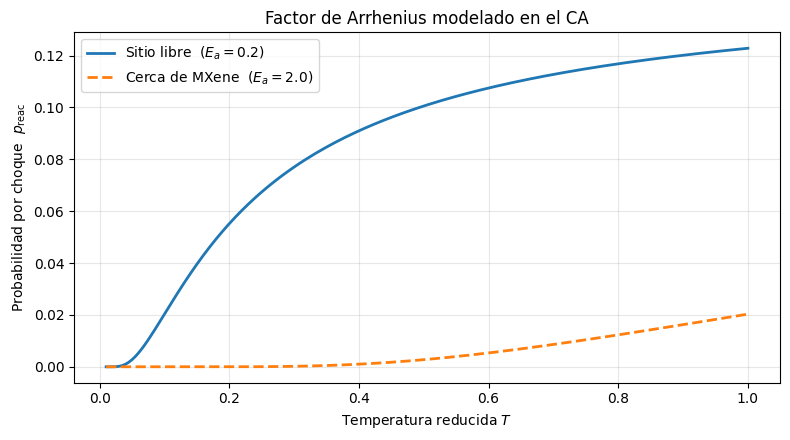

In [3]:
def mef(origen: str, mensaje: str) -> None:
    """Levanta un RuntimeError contextualizado y detiene el programa."""
    raise RuntimeError(f"¡ERROR! {origen} -> {mensaje}")


def fn_reac(t: float, is_free: bool = True) -> float:
    """Probabilidad de reacción A + B -> C + D en función de la temperatura T."""
    return 0.15 * exp(-0.2 / t) if is_free else 0.15 * exp(-2.0 / t)


# Visualicemos rápidamente cómo se comporta fn_reac
ts = np.linspace(0.01, 1.0, 200)
p_libre = [fn_reac(t, is_free=True)  for t in ts]
p_mxene = [fn_reac(t, is_free=False) for t in ts]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ts, p_libre, label="Sitio libre  ($E_a = 0.2$)", lw=2)
ax.plot(ts, p_mxene, label="Cerca de MXene  ($E_a = 2.0$)", lw=2, linestyle="--")
ax.set_xlabel("Temperatura reducida $T$")
ax.set_ylabel("Probabilidad por choque  $p_\\mathrm{reac}$")
ax.set_title("Factor de Arrhenius modelado en el CA")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Ingeniería inversa de la clase `Nodes`

### 4.1 Idea general

Cada **celda** de la grilla 50×50 es un objeto `Nodes`. La clase combina:

- **Atributos de instancia**: el estado químico de la celda, su posición, sus vecinos, banderas
  de movimiento/reacción.
- **Atributos de clase** (compartidos): la lista global `instances`, un diccionario
  `pos_to_id` que traduce coordenadas → índice, y un `banco` que se serializa con pickle.

### 4.2 Estados (`state`)

| Estado | Significado | Color |
|---|---|---|
| 0 | Vacío | gris |
| 1 | Reactante A | rojo |
| 2 | Reactante B | azul |
| 3 | Producto C | verde |
| 4 | Producto D (**gas** — sube y escapa) | violeta |
| 5 | MXene (**fijo**, no se mueve ni reacciona) | naranjo |

### 5.3 El bucle de simulación (lo que pasa en *cada paso*)

**Si `tipo == "mueve"`:**
1. Se calcula `prob_moverse = 0.5 * fn_reac(T)`.
2. Se mezclan todos los nodos móviles en orden aleatorio (Monte Carlo asincrónico).
3. Para cada nodo no movido:
   - Tirada $u \sim \mathcal{U}(0,1)$; si $u \geq p$, se queda quieto.
   - Filtra vecinos válidos (móviles, no movidos, no estado 4).
   - **Si el nodo es estado 4 (gas D)**: restringe a vecinos con `fila ≤ fila_actual`
     → el gas **tiende a subir** (clave para entender el "escape" del producto).
   - Intercambia su `state` con el de un vecino elegido al azar.

**Si `tipo == "reacciona"`:** estructura `match-case` por `state`:
- Estado 1 busca vecinos en estado 2 (reacción $A + B \to C + D$).
- Estado 2 busca estado 1 (simétrico).
- Estado 3 busca estado 4 (reacción inversa, $p_{base} = 10^{-4}$).
- Estado 4 busca estado 3 (simétrico de la inversa).
- La probabilidad efectiva es $p_{base} \cdot \mathrm{fn\_reac}(T, \text{is\_free})$
  multiplicada por el número de vecinos compatibles.


## 5. Implementación de la clase `Nodes`

1. `from typing import Self` añadido.
2. Las constantes de tamaño se reciben por parámetro.
3. Método `reset_class` añadido para reusar la misma instancia entre simulaciones.

In [4]:
class Nodes:
    instances: list[Self] = []
    pos_to_id: dict[tuple[int, int], int] = {}
    banco: list[Any] = [{}, []]
    NF_LY: int = 50
    NC_LX: int = 50

    def __init__(self, pos: tuple[int, int], hm: bool = True, ir: bool = True) -> None:
        self.id: int = len(Nodes.instances)
        self.state: int = 0
        self.new_state: int | None = None
        self.has_mobility: bool = hm
        self.has_moved: bool = False
        self.is_reactive: bool = ir
        self.has_reacted: bool = False
        self.coord: tuple[int, int] = pos
        self.links: list[int] = []
        Nodes.instances.append(self)
        Nodes.pos_to_id[self.coord] = self.id

    def set_fixed(self) -> None:
        self.has_mobility = False
        self.is_reactive = False

    @classmethod
    def all(cls) -> int:
        return len(cls.instances)

    @classmethod
    def reset_class(cls) -> None:
        """Limpia el estado de clase entre simulaciones."""
        cls.instances = []
        cls.pos_to_id = {}
        cls.banco = [{}, []]

    @classmethod
    def reset_flag_movement(cls) -> None:
        for ins in cls.instances:
            ins.has_moved = False

    @classmethod
    def reset_flag_reaction(cls) -> None:
        for ins in cls.instances:
            ins.has_reacted = False

    @classmethod
    def connect(cls, vecindad: str) -> None:
        NF_LY, NC_LX = cls.NF_LY, cls.NC_LX
        for ins in cls.instances:
            f, c = ins.coord
            if vecindad == "von_Neumann":
                deltas = [(-1, 0), (0, 1), (1, 0), (0, -1)]
            elif vecindad == "Moore":
                deltas = [(-1, 0), (-1, 1), (0, 1), (1, 1),
                          (1, 0),  (1, -1), (0, -1), (-1, -1)]
            else:
                mef("Nodes.connect", "Vecindad incorrecta")
            for df, dc in deltas:
                nf = cls.pbc(f + df, NF_LY)
                nc = cls.pbc(c + dc, NC_LX)
                ins.links.append(cls.pos_to_id[(nf, nc)])

    @classmethod
    def nuevo_estado(cls, tipo: str, temperature: float) -> None:
        if tipo == "mueve":
            p_mov = 0.5 * fn_reac(temperature)
            cls.reset_flag_movement()
            scrambled = [ins for ins in cls.instances if ins.has_mobility]
            random.shuffle(scrambled)
            for ins in scrambled:
                if ins.has_moved:
                    continue
                ins.has_moved = True
                if not random.random() < p_mov:
                    continue
                pre = [cls.instances[il] for il in ins.links
                       if cls.instances[il].has_mobility
                       and not cls.instances[il].has_moved
                       and cls.instances[il].state != 4]
                if ins.state == 4:
                    # El gas D tiende a subir: solo puede ir a vecinos arriba o iguales
                    posibles = [p for p in pre if p.coord[0] <= ins.coord[0]]
                else:
                    posibles = pre
                if posibles:
                    otro = random.choice(posibles)
                    ins.state, otro.state = otro.state, ins.state
                    otro.has_moved = True

        elif tipo == "reacciona":
            p_fwd = 1.0
            p_rev = 1e-4
            cls.reset_flag_reaction()
            scrambled = [ins for ins in cls.instances if ins.is_reactive]
            random.shuffle(scrambled)

            for ins in scrambled:
                if ins.has_reacted:
                    continue
                near_mxene = any(cls.instances[il].state == 5 for il in ins.links)
                is_free = not near_mxene

                match ins.state:
                    case 1:
                        partners = [cls.instances[il] for il in ins.links
                                    if cls.instances[il].state == 2
                                    and not cls.instances[il].has_reacted]
                        new_self, new_other = 3, 4
                        p_base = p_fwd
                    case 2:
                        partners = [cls.instances[il] for il in ins.links
                                    if cls.instances[il].state == 1
                                    and not cls.instances[il].has_reacted]
                        new_self, new_other = 4, 3
                        p_base = p_fwd
                    case 3:
                        partners = [cls.instances[il] for il in ins.links
                                    if cls.instances[il].state == 4
                                    and not cls.instances[il].has_reacted]
                        new_self, new_other = 1, 2
                        p_base = p_rev
                    case 4:
                        partners = [cls.instances[il] for il in ins.links
                                    if cls.instances[il].state == 3
                                    and not cls.instances[il].has_reacted]
                        new_self, new_other = 2, 1
                        p_base = p_rev
                    case _:
                        continue

                if not partners:
                    continue
                p = p_base * fn_reac(temperature, is_free)
                if random.random() < len(partners) * p:
                    other = random.choice(partners)
                    ins.state = new_self
                    other.state = new_other
                    ins.has_reacted = True
                    other.has_reacted = True

    @classmethod
    def agrega_banco(cls, donde: Any, que: Any) -> None:
        if isinstance(donde, str) and donde.upper() == "A":
            cls.banco.append(que)
        elif isinstance(donde, int) and donde in (0, 1):
            cls.banco[donde] = que.copy()
        else:
            mef("agrega_banco", "Índice incorrecto")

    @classmethod
    def escribe(cls, ruta: str = "banco.pkl") -> None:
        with open(ruta, "wb") as f:
            pickle.dump(cls.banco, f, -1)

    @staticmethod
    def pbc(ind: int, el_max: int) -> int:
        return ind % el_max

print("Clase Nodes lista")


Clase Nodes lista


## 6. La geometría L — única modificación necesaria

En lugar de las cuatro orientaciones `up/down/right/left` del paper que generan
bloques 5×1 lineales, definimos cuatro orientaciones de L (una por cada rotación
de 90°). Cada L son **5 celdas**, igual que el 5×1 del paper, así que la
**masa total de MXene se conserva**.

### Las 4 orientaciones

```
   "L_dr"          "L_dl"        "L_ur"        "L_ul"
   X . .           . . X         X X X         X X X
   X . .           . . X         X . .         . . X
   X X X           X X X         X . .         . . X
```

(`dr` = corner abajo-derecha, `dl` = abajo-izquierda, `ur` = arriba-derecha,
`ul` = arriba-izquierda)

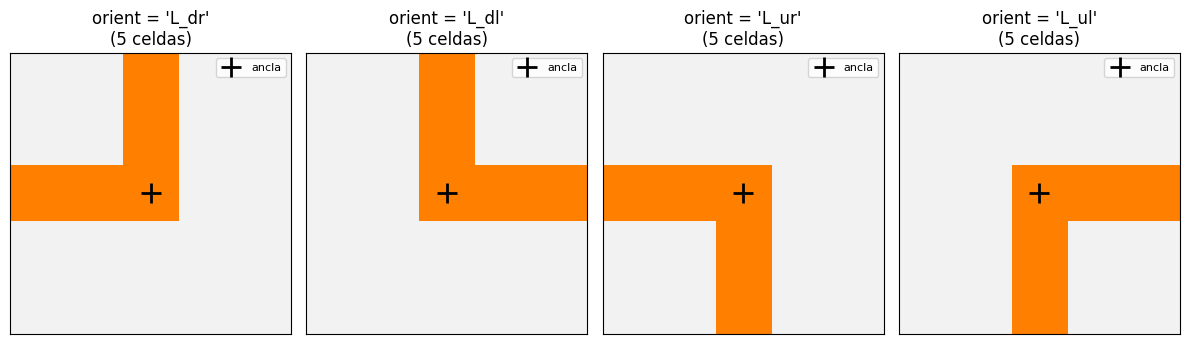

Las 4 orientaciones de la L — todas con 5 celdas, esquina marcada con +


In [5]:
def coords_L(xm0: int, ym0: int, orient: str) -> list[tuple[int, int]]:
    """Devuelve las 5 celdas de una L en una de sus 4 rotaciones."""
    match orient:
        case "L_dr":   # esquina abajo-derecha: brazo arriba y a la izquierda
            return [(xm0, ym0),
                    (xm0 - 1, ym0), (xm0 - 2, ym0),
                    (xm0, ym0 - 1), (xm0, ym0 - 2)]
        case "L_dl":   # esquina abajo-izquierda: brazo arriba y a la derecha
            return [(xm0, ym0),
                    (xm0 - 1, ym0), (xm0 - 2, ym0),
                    (xm0, ym0 + 1), (xm0, ym0 + 2)]
        case "L_ur":   # esquina arriba-derecha: brazo abajo y a la izquierda
            return [(xm0, ym0),
                    (xm0 + 1, ym0), (xm0 + 2, ym0),
                    (xm0, ym0 - 1), (xm0, ym0 - 2)]
        case "L_ul":   # esquina arriba-izquierda: brazo abajo y a la derecha
            return [(xm0, ym0),
                    (xm0 + 1, ym0), (xm0 + 2, ym0),
                    (xm0, ym0 + 1), (xm0, ym0 + 2)]
        case _:
            mef("coords_L", f"Orientación desconocida: {orient}")


# Verificación visual de las 4 orientaciones
fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
for ax, orient in zip(axes, ["L_dr", "L_dl", "L_ur", "L_ul"]):
    M = np.zeros((5, 5))
    for f, c in coords_L(2, 2, orient):
        M[f, c] = 5
    ax.imshow(M, cmap=ListedColormap(["#f2f2f2", "#ff7f00"]),
              vmin=0, vmax=5)
    ax.plot(2, 2, "k+", markersize=15, markeredgewidth=2, label="ancla")
    ax.set_title(f"orient = '{orient}'\n(5 celdas)")
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()
print("Las 4 orientaciones de la L — todas con 5 celdas, esquina marcada con +")


## 7. Inicialización de la grilla

Recreamos el setup del paper: 50×50 con PBC, vecindad de Moore, 1000 unidades
de A y B, 100 bloques de MXene. Mantenemos también una versión **sin MXene** y
una con bloques **5×1 del paper** como referencias.

In [6]:
def coords_5x1(xm0, ym0, orient):
    """Bloque 5×1 original del paper — para comparar."""
    match orient:
        case "up":    return [(xm0, ym0 - k) for k in range(5)]
        case "down":  return [(xm0, ym0 + k) for k in range(5)]
        case "right": return [(xm0 + k, ym0) for k in range(5)]
        case "left":  return [(xm0 - k, ym0) for k in range(5)]


# Diccionario: nombre → (función generadora, orientaciones, margen, celdas/bloque)
SHAPES = {
    "5x1 (paper)": (coords_5x1, ["up", "down", "right", "left"], 4, 5),
    "L":           (coords_L,   ["L_dr", "L_dl", "L_ur", "L_ul"], 3, 5),
}


def build_grid(NF_LY: int = 50,
               NC_LX: int = 50,
               n_A: int = 1000,
               n_B: int = 1000,
               shape: str | None = None,
               num_mxene: int = 100,
               vecindad: str = "Moore",
               seed: int | None = 42,
               verbose: bool = True) -> None:
    """Construye una grilla limpia con reactantes y (opcionalmente) MXenes.

    Parameters
    ----------
    shape : str | None
        Nombre de la geometría: "5x1 (paper)", "L", o None (sin MXene).
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    Nodes.reset_class()
    Nodes.NF_LY = NF_LY
    Nodes.NC_LX = NC_LX

    # 1) Crear celdas vacías
    for f in range(NF_LY):
        for c in range(NC_LX):
            Nodes((f, c))

    # 2) Conectar topología
    Nodes.connect(vecindad)

    # 3) Metadatos
    Nodes.agrega_banco(0, {
        "NF_LY": NF_LY, "NC_LX": NC_LX,
        "width_tile": 20, "height_tile": 20, "margin_tile": 3,
    })

    # 4) Sembrar MXenes (si shape is not None)
    if shape is not None:
        coords_fn, orientaciones, margen, celdas_por_bloque = SHAPES[shape]
        sembrados, intentos = 0, 0
        max_intentos = num_mxene * 200
        while sembrados < num_mxene and intentos < max_intentos:
            intentos += 1
            xm0 = random.choice(range(margen, NF_LY - margen))
            ym0 = random.choice(range(margen, NC_LX - margen))
            orient = random.choice(orientaciones)
            candidatas = coords_fn(xm0, ym0, orient)
            # CAMBIO CLAVE vs paper: verificar TODAS las celdas, no solo el ancla
            if not all(Nodes.instances[Nodes.pos_to_id[c]].state == 0
                       for c in candidatas):
                continue
            for tc in candidatas:
                node = Nodes.instances[Nodes.pos_to_id[tc]]
                node.state = 5
                node.set_fixed()
            sembrados += 1
        if verbose:
            print(f"  → {shape}: {sembrados}/{num_mxene} bloques sembrados "
                  f"({sembrados * celdas_por_bloque} celdas, {intentos} intentos)")

    # 5) Sembrar reactantes — random.sample evita bucles infinitos
    indices_vacios = [i for i, n in enumerate(Nodes.instances) if n.state == 0]
    if n_A + n_B > len(indices_vacios):
        raise RuntimeError(f"No caben {n_A + n_B} reactantes en {len(indices_vacios)} huecos")
    elegidos = random.sample(indices_vacios, n_A + n_B)
    for i, idx in enumerate(elegidos):
        Nodes.instances[idx].state = 1 if i < n_A else 2

    # 6) Snapshot inicial
    Nodes.agrega_banco(1, [
        (Nodes.instances[i].coord, Nodes.instances[i].state)
        for i in range(Nodes.all())
    ])


def grid_to_array() -> np.ndarray:
    """Vuelca el estado actual de la grilla a una matriz NumPy."""
    M = np.zeros((Nodes.NF_LY, Nodes.NC_LX), dtype=int)
    for n in Nodes.instances:
        f, c = n.coord
        M[f, c] = n.state
    return M


def count_species(M: np.ndarray) -> dict[int, int]:
    return {s: int((M == s).sum()) for s in range(6)}


# Construimos los TRES sistemas que compararemos
print("Construyendo sistemas:")
print("\n[Sin MXene]")
build_grid(shape=None, seed=SEED)
grid_pure = grid_to_array()

print("\n[5×1 (paper)]")
build_grid(shape="5x1 (paper)", seed=SEED)
grid_5x1 = grid_to_array()

print("\n[L]")
build_grid(shape="L", seed=SEED)
grid_L = grid_to_array()

print("\nResumen:")
for nombre, M in [("Sin MXene", grid_pure), ("5×1", grid_5x1), ("L", grid_L)]:
    c = count_species(M)
    print(f"  {nombre:<12}  A={c[1]}, B={c[2]}, MXene={c[5]}")


Construyendo sistemas:

[Sin MXene]

[5×1 (paper)]
  → 5x1 (paper): 100/100 bloques sembrados (500 celdas, 166 intentos)

[L]
  → L: 100/100 bloques sembrados (500 celdas, 169 intentos)

Resumen:
  Sin MXene     A=1000, B=1000, MXene=0
  5×1           A=1000, B=1000, MXene=500
  L             A=1000, B=1000, MXene=500


## 8. Visualización — malla inicial de las 3 configuraciones

Vista panorámica + zoom para apreciar las geometrías.

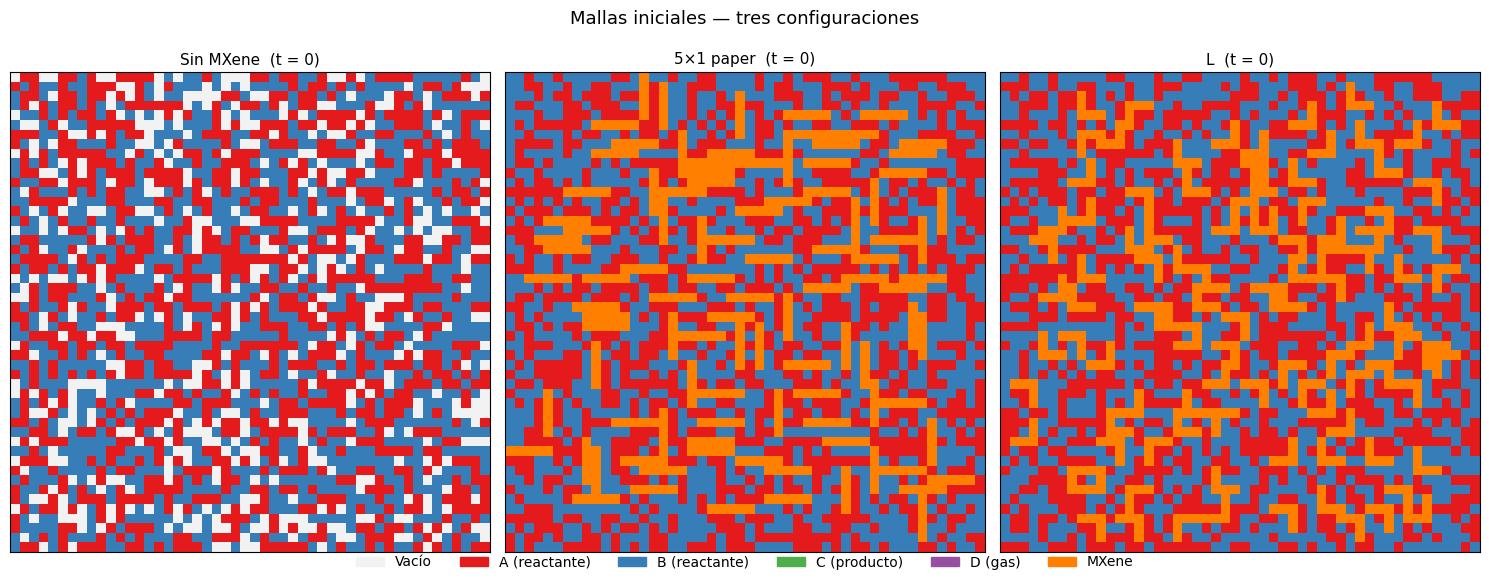

In [8]:
COLORES = ["#f2f2f2", "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
ETIQUETAS = ["Vacío", "A (reactante)", "B (reactante)",
             "C (producto)", "D (gas)", "MXene"]
CMAP = ListedColormap(COLORES)
NORM = BoundaryNorm(np.arange(-0.5, len(COLORES) + 0.5, 1), CMAP.N)


def plot_malla(matriz, titulo, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(matriz, cmap=CMAP, norm=NORM, interpolation="nearest")
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])


# Vista panorámica de las 3 configuraciones
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
plot_malla(grid_pure, "Sin MXene  (t = 0)",     ax=axes[0])
plot_malla(grid_5x1,  "5×1 paper  (t = 0)",     ax=axes[1])
plot_malla(grid_L,    "L  (t = 0)",             ax=axes[2])

handles = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORES, ETIQUETAS)]
fig.legend(handles=handles, loc="lower center", ncol=6, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Mallas iniciales — tres configuraciones", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 9. Gestión de datos — ¿Dónde se guardan los resultados?

| Mecanismo | Tipo | Contenido |
|---|---|---|
| `Nodes.instances` | Lista en memoria | Todos los nodos vivos con su `state` actual |
| `Nodes.banco[0]` | Dict en memoria | Metadatos de configuración |
| `Nodes.banco[1]` | Lista en memoria | Snapshot **inicial** de `(coord, state)` |
| `Nodes.banco[2:]` | Lista en memoria | Snapshots añadidos con `agrega_banco("A", ...)` |
| `banco.pkl` | **Archivo en disco** | Se crea cuando se llama `Nodes.escribe()` |
| `print(temperature porcentaje)` | **stdout** | Único resultado cuantitativo que sale del simulador |

In [30]:
# Demo: snapshot del banco después de construir la grilla
print("Banco después de build_grid (con L):")
print(f"  banco[0] (config):     {Nodes.banco[0]}")
print(f"  banco[1] (snapshot 0): lista con {len(Nodes.banco[1])} entradas")
print(f"  Primeras 3 entradas:   {Nodes.banco[1][:3]}")

Nodes.escribe(ruta="banco_inicial_L.pkl")
print("\nSnapshot guardado en banco_inicial_L.pkl")


Banco después de build_grid (con L):
  banco[0] (config):     {'NF_LY': 50, 'NC_LX': 50, 'width_tile': 20, 'height_tile': 20, 'margin_tile': 3}
  banco[1] (snapshot 0): lista con 2500 entradas
  Primeras 3 entradas:   [((0, 0), 2), ((0, 1), 2), ((0, 2), 1)]

Snapshot guardado en banco_inicial_L.pkl


## 10. Primeras iteraciones — el sistema en movimiento

Avanzamos **2 iteraciones** en cada configuración (cada iteración = un paso de
*movimiento* + un paso de *reacción*) a `T = 0.5`.

In [31]:
def run_and_snapshot(n_iter: int, temperature: float) -> list[np.ndarray]:
    snapshots = [grid_to_array()]
    for _ in range(n_iter):
        Nodes.nuevo_estado("mueve", temperature)
        Nodes.nuevo_estado("reacciona", temperature)
        snapshots.append(grid_to_array())
    return snapshots


T_test = 0.5

build_grid(shape=None,          seed=SEED, verbose=False)
snaps_pure = run_and_snapshot(n_iter=2, temperature=T_test)

build_grid(shape="5x1 (paper)", seed=SEED, verbose=False)
snaps_5x1 = run_and_snapshot(n_iter=2, temperature=T_test)

build_grid(shape="L",           seed=SEED, verbose=False)
snaps_L = run_and_snapshot(n_iter=2, temperature=T_test)

# Resumen tabular
print(f"\nConteo de especies por snapshot (T = {T_test}):\n")
print(f"{'iter':>5} | {'config':<10} | {'A':>5} {'B':>5} {'C':>5} {'D':>5} {'MX':>5}")
print("-" * 55)
for i in range(3):
    for nombre, snaps in [("sin MX", snaps_pure), ("5x1", snaps_5x1), ("L", snaps_L)]:
        c = count_species(snaps[i])
        print(f"{i:>5} | {nombre:<10} | {c[1]:>5} {c[2]:>5} {c[3]:>5} {c[4]:>5} {c[5]:>5}")



Conteo de especies por snapshot (T = 0.5):

 iter | config     |     A     B     C     D    MX
-------------------------------------------------------
    0 | sin MX     |  1000  1000     0     0     0
    0 | 5x1        |  1000  1000     0     0   500
    0 | L          |  1000  1000     0     0   500
    1 | sin MX     |   535   535   465   465     0
    1 | 5x1        |   714   714   286   286   500
    1 | L          |   745   745   255   255   500
    2 | sin MX     |   403   403   597   597     0
    2 | 5x1        |   619   619   381   381   500
    2 | L          |   645   645   355   355   500


### Visualización de las 2 iteraciones 


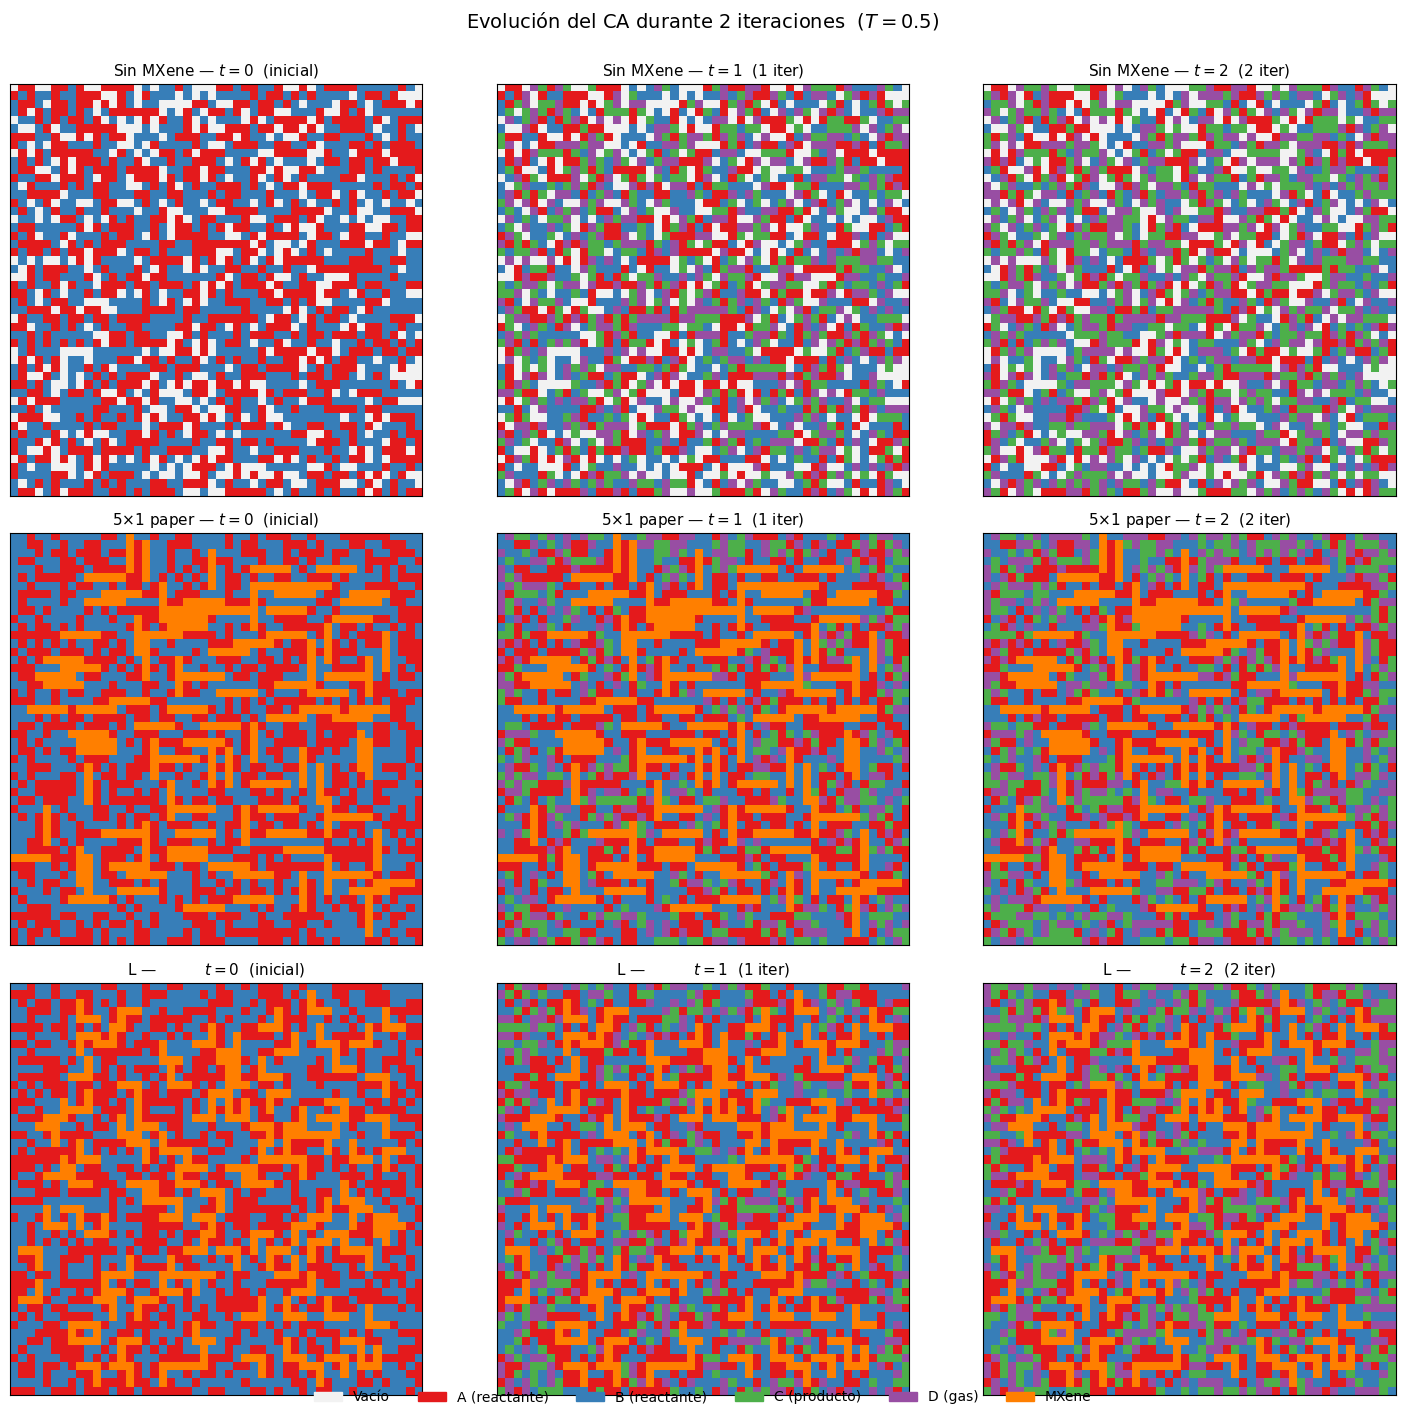

In [32]:
fig, axes = plt.subplots(3, 3, figsize=(15, 14))
titulos_t = ["$t = 0$  (inicial)", "$t = 1$  (1 iter)", "$t = 2$  (2 iter)"]

for j in range(3):
    plot_malla(snaps_pure[j], f"Sin MXene — {titulos_t[j]}", ax=axes[0, j])
    plot_malla(snaps_5x1[j],  f"5×1 paper — {titulos_t[j]}", ax=axes[1, j])
    plot_malla(snaps_L[j],    f"L —          {titulos_t[j]}", ax=axes[2, j])

handles = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORES, ETIQUETAS)]
fig.legend(handles=handles, loc="lower center", ncol=6, frameon=False,
           bbox_to_anchor=(0.5, -0.005))
fig.suptitle(f"Evolución del CA durante 2 iteraciones  ($T = {T_test}$)",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()


## 11. Gráficos de comparación

Hacemos una prueba más larga: **30 iteraciones a T = 0.5**,
midiendo el consumo de reactante A y la formación del gas D en cada paso, para las tres configuraciones.

Simulando 3 configuraciones...
Listo.



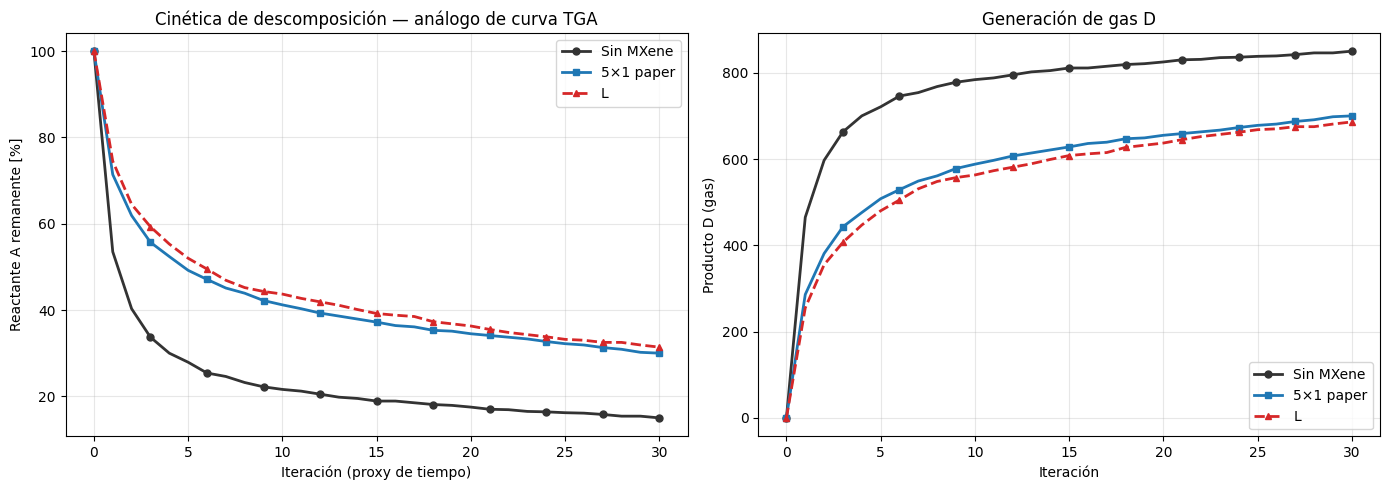

In [36]:
def run_track(n_iter, temperature):
    historial = [count_species(grid_to_array())]
    for _ in range(n_iter):
        Nodes.nuevo_estado("mueve", temperature)
        Nodes.nuevo_estado("reacciona", temperature)
        historial.append(count_species(grid_to_array()))
    return historial


N_ITER = 30

print("Simulando 3 configuraciones...")
build_grid(shape=None,          seed=SEED, verbose=False)
hist_pure = run_track(N_ITER, T_test)

build_grid(shape="5x1 (paper)", seed=SEED, verbose=False)
hist_5x1 = run_track(N_ITER, T_test)

build_grid(shape="L",           seed=SEED, verbose=False)
hist_L = run_track(N_ITER, T_test)

print("Listo.\n")

estilos = {
    "Sin MXene":  {"color": "#333333", "ls": "-",  "marker": "o"},
    "5×1 paper":  {"color": "#1f77b4", "ls": "-",  "marker": "s"},
    "L":          {"color": "#d62728", "ls": "--", "marker": "^"},
}
datos = {
    "Sin MXene":  hist_pure,
    "5×1 paper":  hist_5x1,
    "L":          hist_L,
}

iters = np.arange(N_ITER + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# (a) Reactante A remanente en %
for nombre, hist in datos.items():
    A = np.array([h[1] for h in hist])
    pct = 100 * A / A[0]
    ax1.plot(iters, pct, label=nombre, lw=2, markersize=5,
             markevery=3, **estilos[nombre])
ax1.set_xlabel("Iteración (proxy de tiempo)")
ax1.set_ylabel("Reactante A remanente [%]")
ax1.set_title("Cinética de descomposición — análogo de curva TGA")
ax1.grid(alpha=0.3); ax1.legend()

# (b) Producto D acumulado
for nombre, hist in datos.items():
    D = np.array([h[4] for h in hist])
    ax2.plot(iters, D, label=nombre, lw=2, markersize=5,
             markevery=3, **estilos[nombre])
ax2.set_xlabel("Iteración")
ax2.set_ylabel("Producto D (gas)")
ax2.set_title("Generación de gas D")
ax2.grid(alpha=0.3); ax2.legend()

plt.tight_layout()
plt.show()


### Tabla resumen de los 3 escenarios

In [37]:
print(f"{'Config':<14} {'A inicial':>10} {'A final':>10} "
      f"{'% consumido':>12} {'D final':>10}")
print("-" * 60)
for nombre, hist in datos.items():
    A0 = hist[0][1]; Af = hist[-1][1]; Df = hist[-1][4]
    pct = 100 * (A0 - Af) / A0
    print(f"{nombre:<14} {A0:>10} {Af:>10} {pct:>11.1f}% {Df:>10}")


Config          A inicial    A final  % consumido    D final
------------------------------------------------------------
Sin MXene            1000        150        85.0%        850
5×1 paper            1000        300        70.0%        700
L                    1000        314        68.6%        686


## 12. Réplicas múltiples — ¿es robusta la diferencia?

Una sola corrida con `seed=42` puede ser engañosa. Repetimos el experimento con
**10 semillas distintas** y graficamos el promedio ± desviación estándar para cada geometría.

In [38]:
N_REPLICAS = 10
configs_a_correr = ["Sin MXene", "5×1 paper", "L"]
shape_map = {"Sin MXene": None, "5×1 paper": "5x1 (paper)", "L": "L"}

resultados = {nombre: [] for nombre in configs_a_correr}

print(f"Corriendo {N_REPLICAS} réplicas × {len(configs_a_correr)} configuraciones...")
for rep in range(N_REPLICAS):
    seed_rep = 1000 + rep
    for nombre in configs_a_correr:
        build_grid(shape=shape_map[nombre], seed=seed_rep, verbose=False)
        hist = run_track(N_ITER, T_test)
        A_remanente = np.array([h[1] for h in hist])
        resultados[nombre].append(100 * A_remanente / A_remanente[0])
    print(f"  Réplica {rep + 1}/{N_REPLICAS} OK")

resultados_arr = {nombre: np.array(rs) for nombre, rs in resultados.items()}
print("\nListo.")


Corriendo 10 réplicas × 3 configuraciones...
  Réplica 1/10 OK
  Réplica 2/10 OK
  Réplica 3/10 OK
  Réplica 4/10 OK
  Réplica 5/10 OK
  Réplica 6/10 OK
  Réplica 7/10 OK
  Réplica 8/10 OK
  Réplica 9/10 OK
  Réplica 10/10 OK

Listo.


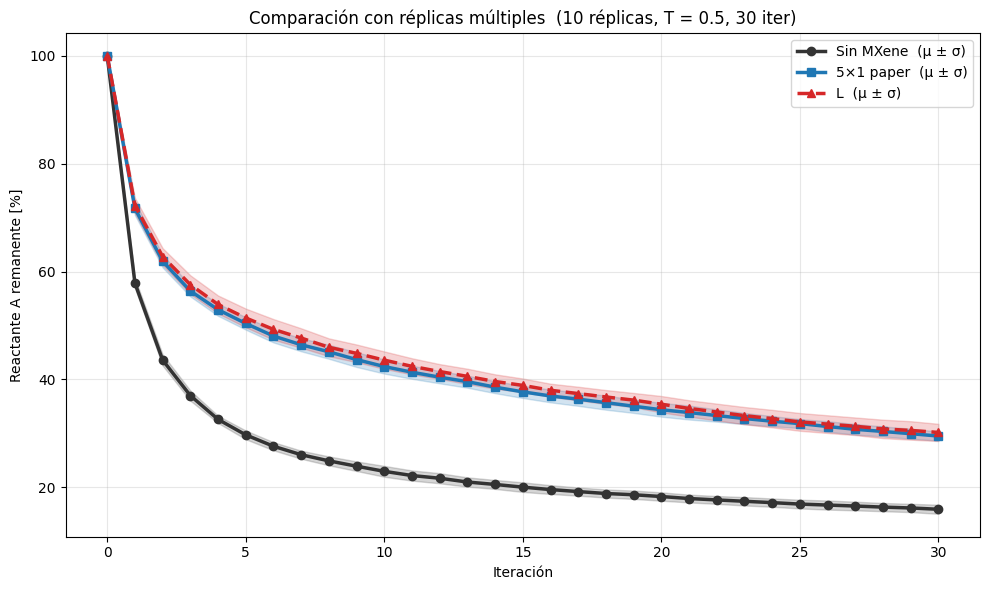


Config               % A final      ± σ
------------------------------------------
Sin MXene                15.9%     0.84
5×1 paper                29.5%     0.83
L                        30.2%     1.60


In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

for nombre, arr in resultados_arr.items():
    media = arr.mean(axis=0)
    std   = arr.std(axis=0)
    ax.plot(iters, media, label=f"{nombre}  (μ ± σ)", lw=2.5, **estilos[nombre])
    ax.fill_between(iters, media - std, media + std,
                    color=estilos[nombre]["color"], alpha=0.20)

ax.set_xlabel("Iteración")
ax.set_ylabel("Reactante A remanente [%]")
ax.set_title(f"Comparación con réplicas múltiples  "
             f"({N_REPLICAS} réplicas, T = {T_test}, {N_ITER} iter)")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

print(f"\n{'Config':<14} {'% A final':>15} {'± σ':>8}")
print("-" * 42)
for nombre, arr in resultados_arr.items():
    final = arr[:, -1]
    print(f"{nombre:<14} {final.mean():>14.1f}%  {final.std():>7.2f}")


# Inciso final — prueba rápida con tira 10×1

Hasta ahora vimos que la **L no aporta mucho sobre el 5×1** a igualdad de masa.
Una pregunta natural: ¿y si vamos al **extremo opuesto** y alargamos el bloque?
Una tira 10×1 — el doble de larga que la del paper.

Esto modela la posibilidad de **agregación entre nanoláminas**: dos MXenes 5×1
que se pegan formando un objeto más largo. El propio paper menciona esto como
preocupación (§3.2):

> *"higher concentrations may lead to undesired agglomeration effects, which
> may also induce downgraded thermal properties."*

¿Qué dice el modelo CA computacionalmente?


## 13. Definición de la tira 10×1

Es la extensión más natural del 5×1: cambiar `range(5)` a `range(10)`. 

In [41]:
def coords_10x1(xm0: int, ym0: int, orient: str) -> list[tuple[int, int]]:
    """Bloque 10×1 lineal — extensión natural del 5×1 del paper."""
    match orient:
        case "up":    return [(xm0, ym0 - k) for k in range(10)]
        case "down":  return [(xm0, ym0 + k) for k in range(10)]
        case "right": return [(xm0 + k, ym0) for k in range(10)]
        case "left":  return [(xm0 - k, ym0) for k in range(10)]
        case _:
            mef("coords_10x1", f"Orientación desconocida: {orient}")


# Registrar la nueva forma — margen=9 porque la tira ocupa 10 celdas
SHAPES["10x1"] = (coords_10x1, ["up", "down", "right", "left"], 9, 10)
print("Forma 10×1 registrada.")


Forma 10×1 registrada.


## 14. Construcción de la configuración 10×1

**Para comparar a igualdad de masa MXene** con el paper (500 celdas totales):
- 5×1 paper → 100 bloques × 5 celdas = 500 celdas MXene
- 10×1      → **50 bloques** × 10 celdas = 500 celdas MXene

Mismo número total de celdas MXene, pero repartidas en la mitad de bloques.

  → 10x1: 50/50 bloques sembrados (500 celdas, 152 intentos)

Estados presentes: A=1000, B=1000, MXene=500


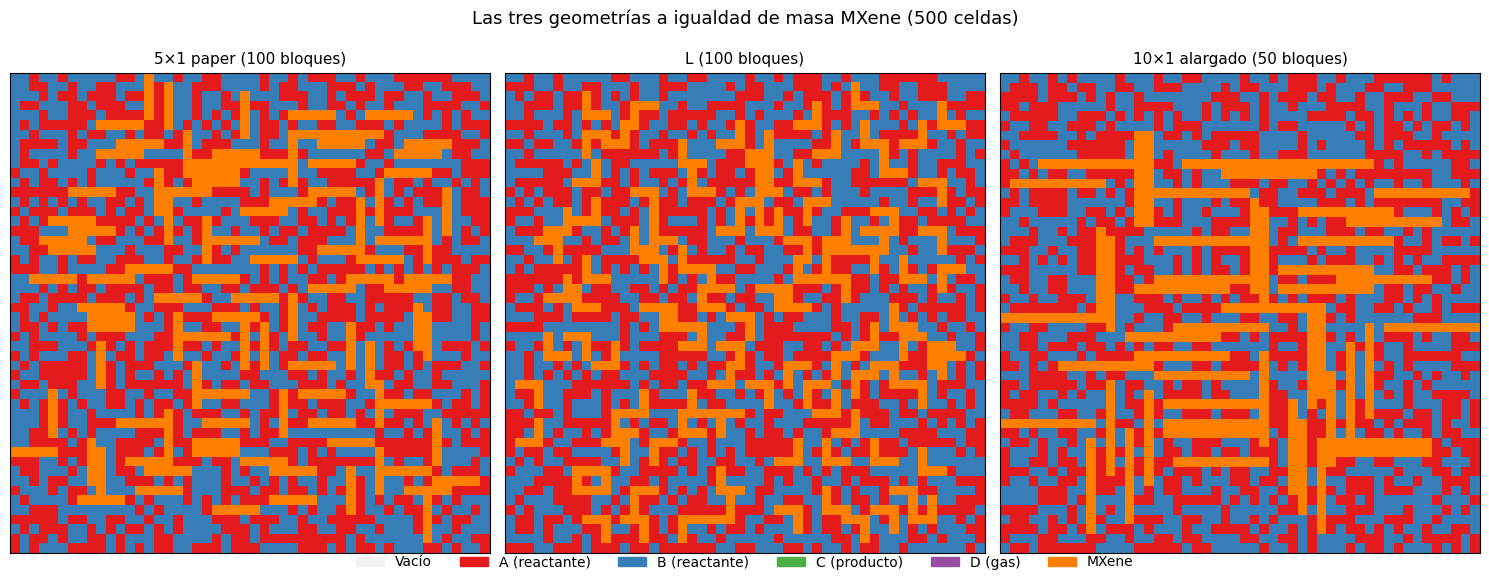

In [42]:
# Construir la configuración 10×1 con 50 bloques
build_grid(shape="10x1", num_mxene=50, seed=SEED)
grid_10x1 = grid_to_array()

c = count_species(grid_10x1)
print(f"\nEstados presentes: A={c[1]}, B={c[2]}, MXene={c[5]}")

# Visualización lado a lado con 5×1 y L
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
plot_malla(grid_5x1,  "5×1 paper (100 bloques)",    ax=axes[0])
plot_malla(grid_L,    "L (100 bloques)",             ax=axes[1])
plot_malla(grid_10x1, "10×1 alargado (50 bloques)",  ax=axes[2])

handles = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORES, ETIQUETAS)]
fig.legend(handles=handles, loc="lower center", ncol=6, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Las tres geometrías a igualdad de masa MXene (500 celdas)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
